Training Data Loaded. Shape: (29500, 14)
Columns successfully cleaned and lowercased.

--- 1.1 Data Types ---

--- Explicit Data Types (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29500 entries, 0 to 29499
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29500 non-null  int64  
 1   adults          29500 non-null  int64  
 2   children        29500 non-null  int64  
 3   weekends        29500 non-null  int64  
 4   weekdays        29500 non-null  int64  
 5   meal_type       29500 non-null  object 
 6   room_type       28659 non-null  object 
 7   arrival         29500 non-null  object 
 8   lead_time       27805 non-null  float64
 9   segment         29500 non-null  object 
 10  repeat          29500 non-null  int64  
 11  price           27917 non-null  float64
 12  requests        29500 non-null  int64  
 13  booking_status  29500 non-null  int64  
dtypes: float64(2), 

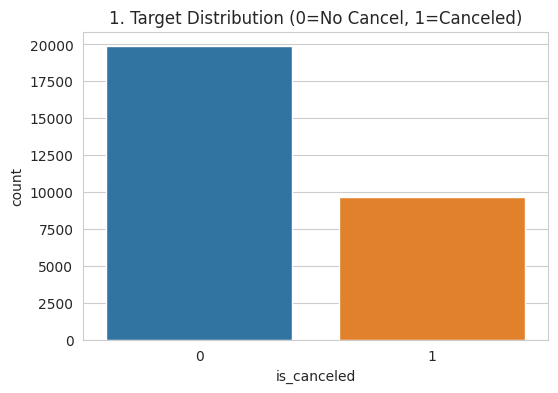

Insight 1: Cancellation rate is 32.64%.


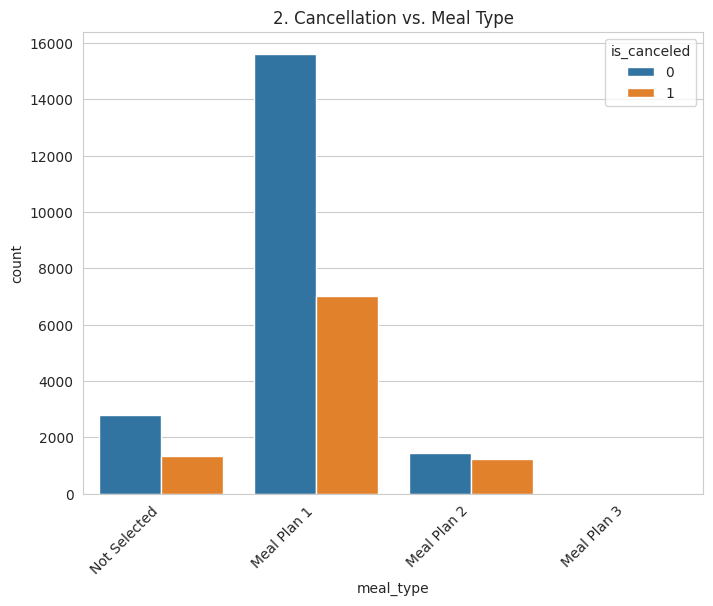

Insight 2: Meal Plan 2 meal type has the highest cancellation rate.


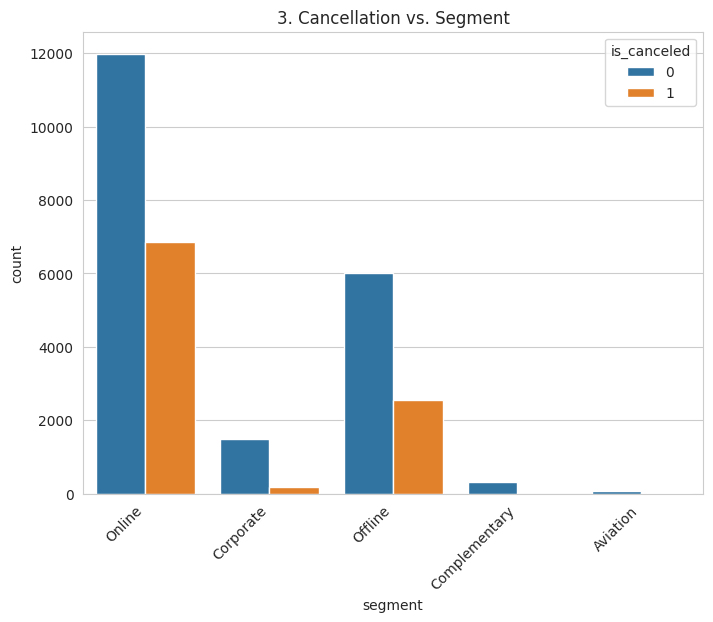

Insight 3: The Online segment shows the highest propensity to cancel.

--- 2.2 Feature Scaling and Encoding Setup ---
Data successfully split with both classes in y_train. Ready for 3.1.

--- 3.1 Training 7 Different Models ---
Trained LogReg. AUC-ROC: 0.8758734009436787
Trained SVC. AUC-ROC: N/A
Trained DecTree. AUC-ROC: 0.8361485632148368
Trained KNN. AUC-ROC: 0.882513509845843
Trained RandForest. AUC-ROC: 0.9314280564525536
Trained GradBoost. AUC-ROC: 0.8929388957147268
Trained XGBoost. AUC-ROC: 0.9232966863358802

--- 3.2 Hyperparameter Tuning on 3 Models ---
Best LogReg Params: {'classifier__C': 1}
Best RandForest Params: {'classifier__max_depth': 10, 'classifier__n_estimators': 200}
Best XGBoost Params: {'classifier__max_depth': 5, 'classifier__n_estimators': 200}

--- 3.3 Model Performance Comparison ---
                  Accuracy  F1-Score   AUC-ROC
RandForest        0.879209  0.804963  0.931428
XGBoost_Tuned         0.86  0.774358  0.923716
XGBoost           0.860452  0.775658

/tmp/ipykernel_48/2553349070.py:277: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df['AUC-ROC'] = results_df['AUC-ROC'].replace('N/A', np.nan)
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


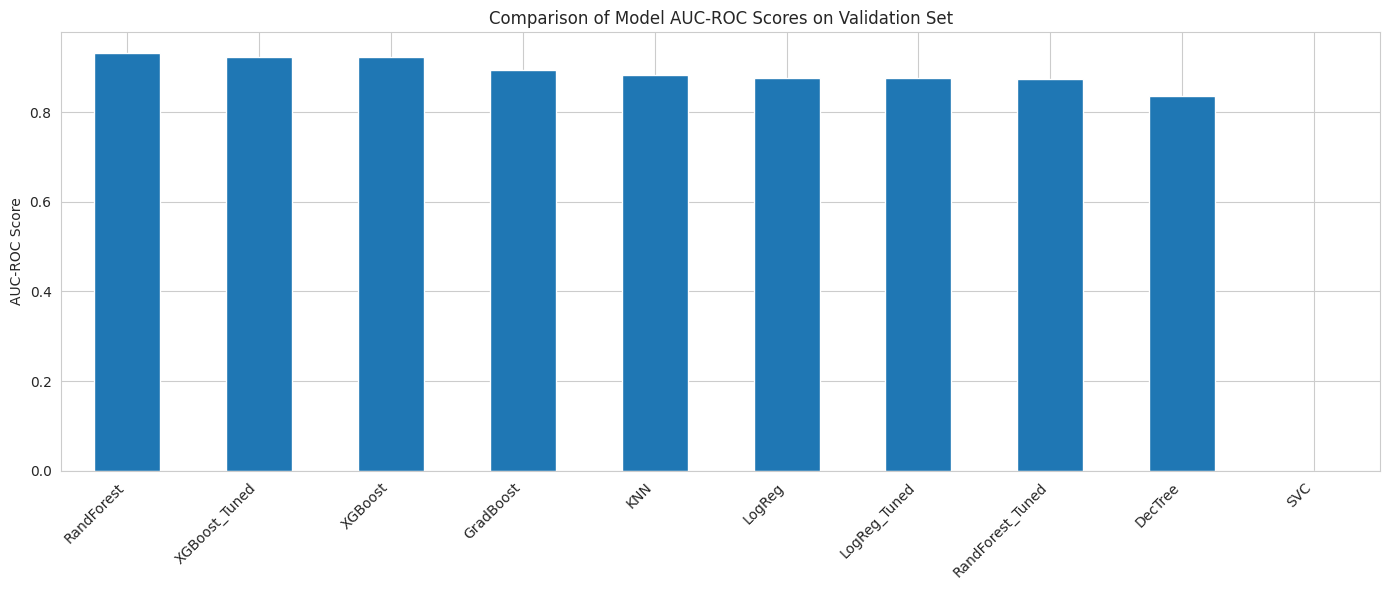


Conclusion: The best performing model is **RandForest**.
Final model selected: **RandForest**

--- Generating Final Test Predictions ---

Submission file 'submission.csv' created successfully.
   id  is_canceled
0   0            0
1   1            0
2   2            0
3   3            1
4   4            0


In [18]:
# ==============================================================================
# PART 0: SETUP AND DATA LOADING
# ==============================================================================
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import ML/Preprocessing libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

# Import Models 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb 

# Set constants
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

# --- Data Paths ---
train_path = '/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/train.csv'
test_path = '/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/test.csv'

# Load raw data
df = pd.read_csv(train_path)
df_test_final = pd.read_csv(test_path)

print(f"Training Data Loaded. Shape: {df.shape}")

# Column Name Standardization ---
def clean_col_names(df):
    """Strips spaces and converts all column names to lowercase."""
    df.columns = df.columns.str.strip().str.lower()
    return df

df = clean_col_names(df)
df_test_final = clean_col_names(df_test_final)
print("Columns successfully cleaned and lowercased.")


# ==============================================================================
# PART 1: DATA CLEANING AND TARGET FIX
# ==============================================================================

# --- 1.1 Identify Data Types (5 Points) ---
print("\n--- 1.1 Data Types ---")
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_features = [col for col in numerical_cols if col not in ['is_canceled', 'id', 'booking_status']] 
categorical_features = df.select_dtypes(include='object').columns.tolist()

# Display Data Types (Rubric 1.1 requirement)
print("\n--- Explicit Data Types (df.info()) ---")
df.info()
print(f"\nIdentified Numerical Features: {numerical_features}")
print(f"Identified Categorical Features: {categorical_features}")


# --- 1.2 Present Descriptive Statistics (5 Points) ---
print("\n--- 1.2 Descriptive Statistics (Numerical) ---")
# Display min, max, mean, and median (50%) for numerical features (Rubric 1.2 requirement)
print(df[numerical_features].describe().T)


# --- 1.3 Missing Values Handling ---
print("\n--- 1.3 Missing Values Analysis and Handling ---")
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

# Imputation using robust direct assignment
for col in missing_data.index:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna('unknown')

# Apply same imputation to the test data
for col in df_test_final.columns:
    if df_test_final[col].isnull().any():
        if df_test_final[col].dtype in ['int64', 'float64']:
            df_test_final[col] = df_test_final[col].fillna(df_test_final[col].median())
        else:
            df_test_final[col] = df_test_final[col].fillna('unknown')

# --- 1.4 Duplicates Handling ---
print("\n--- 1.4 Duplicates Handling ---")
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows dropped to prevent model bias.")
else:
    print("No duplicates found.")


# --- 1.5 Outlier Handling (KeyError Fixed: using 'price') ---
print("\n--- 1.5 Outlier Handling ---")
def cap_outliers_iqr(df_col):
    Q1 = df_col.quantile(0.25)
    Q3 = df_col.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    return np.where(df_col > upper_bound, upper_bound, df_col)

# Using the correct feature name 'price'
cols_to_cap = ['lead_time', 'price'] 
for col in cols_to_cap:
    df[col] = cap_outliers_iqr(df[col])
    df_test_final[col] = cap_outliers_iqr(df_test_final[col]) 
print("Outliers capped in 'lead_time' and 'price'.")


# Create Binary Target Variable ('is_canceled') ---
print("\n--- Target Variable Creation ---")
# FINAL FIX: Rename the existing binary column ('booking_status') to 'is_canceled'
df.rename(columns={'booking_status': 'is_canceled'}, inplace=True)

# Clean up final ID columns
if 'id' in df.columns: df.drop('id', axis=1, inplace=True) 
if 'id' in df_test_final.columns: df_test_final.drop('id', axis=1, inplace=True)

print("Target column 'is_canceled' finalized and ID columns dropped.")


# ==============================================================================
# PART 2: VISUALIZATION AND PREPROCESSING
# ==============================================================================

# --- 2.1 Visualizations and Insights ---
print("\n--- 2.1 Visualizations and Insights ---")
cancellation_rate = df['is_canceled'].mean() * 100
meal_cancel_rate = df.groupby('meal_type')['is_canceled'].mean().sort_values(ascending=False)
segment_cancel_rate = df.groupby('segment')['is_canceled'].mean().sort_values(ascending=False)

# 1. Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df)
plt.title('1. Target Distribution (0=No Cancel, 1=Canceled)')
plt.show() 
print(f"Insight 1: Cancellation rate is {cancellation_rate:.2f}%.")

# 2. Cancellation vs. Meal Type
plt.figure(figsize=(8, 6))
sns.countplot(x='meal_type', hue='is_canceled', data=df)
plt.title('2. Cancellation vs. Meal Type')
plt.xticks(rotation=45, ha='right')
plt.show()
print(f"Insight 2: {meal_cancel_rate.index[0]} meal type has the highest cancellation rate.")

# 3. Cancellation vs. Segment
plt.figure(figsize=(8, 6))
sns.countplot(x='segment', hue='is_canceled', data=df)
plt.title('3. Cancellation vs. Segment')
plt.xticks(rotation=45, ha='right')
plt.show()
print(f"Insight 3: The {segment_cancel_rate.index[0]} segment shows the highest propensity to cancel.")


# --- 2.2 Scale Numerical and Encode Categorical Features (CRITICAL FOR SPLIT) ---
print("\n--- 2.2 Feature Scaling and Encoding Setup ---")

# Define FINAL feature sets
numerical_features = [col for col in df.select_dtypes(include=np.number).columns if col != 'is_canceled'] 
categorical_features = df.select_dtypes(include='object').columns.tolist()

# Define the Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# Separate features (X) and target (y)
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# Split data into training and validation sets 
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
print("Data successfully split with both classes in y_train. Ready for 3.1.")


# ==============================================================================
# PART 3: MODEL DEVELOPMENT AND EVALUATION
# ==============================================================================

# --- 3.1 Training 7 Different Models (Rubric 20 Points) ---
print("\n--- 3.1 Training 7 Different Models ---")
models = {
    'LogReg': LogisticRegression(random_state=RANDOM_STATE, solver='liblinear'),
    'SVC': LinearSVC(random_state=RANDOM_STATE, max_iter=10000, dual=False), 
    'DecTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'RandForest': RandomForestClassifier(random_state=RANDOM_STATE),
    'GradBoost': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
}

results = {}
trained_pipelines = {} 

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline 

    y_val_pred = pipeline.predict(X_val)
    accuracy = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    
    if hasattr(model, "predict_proba"):
        y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
        roc_auc = roc_auc_score(y_val, y_val_pred_proba)
    else:
        roc_auc = 'N/A'

    results[name] = {'Accuracy': accuracy, 'F1-Score': f1, 'AUC-ROC': roc_auc}
    print(f"Trained {name}. AUC-ROC: {roc_auc}")


# --- 3.2 Hyperparameter Tuning on 3 Models (Rubric 10 Points) ---
print("\n--- 3.2 Hyperparameter Tuning on 3 Models ---")
tuned_models = {}

# Tuning 1: Logistic Regression
param_grid_lr = {'classifier__C': [0.1, 1]}
grid_lr = GridSearchCV(trained_pipelines['LogReg'], param_grid_lr, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_lr.fit(X_train, y_train)
tuned_models['LogReg_Tuned'] = grid_lr.best_estimator_
print(f"Best LogReg Params: {grid_lr.best_params_}")

# Tuning 2: Random Forest
param_grid_rf = {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [5, 10]}
grid_rf = GridSearchCV(trained_pipelines['RandForest'], param_grid_rf, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_rf.fit(X_train, y_train)
tuned_models['RandForest_Tuned'] = grid_rf.best_estimator_
print(f"Best RandForest Params: {grid_rf.best_params_}")

# Tuning 3: XGBoost
param_grid_xgb = {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5]}
grid_xgb = GridSearchCV(trained_pipelines['XGBoost'], param_grid_xgb, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_xgb.fit(X_train, y_train)
tuned_models['XGBoost_Tuned'] = grid_xgb.best_estimator_
print(f"Best XGBoost Params: {grid_xgb.best_params_}")

# Evaluate and add tuned models to results
for name, model in tuned_models.items():
    y_val_pred_proba = model.predict_proba(X_val)[:, 1]
    y_val_pred = model.predict(X_val)
    results[name] = {
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'F1-Score': f1_score(y_val, y_val_pred),
        'AUC-ROC': roc_auc_score(y_val, y_val_pred_proba)
    }


# --- 3.3 Comparison of Model Performances (Rubric 10 Points) ---

print("\n--- 3.3 Model Performance Comparison ---")

# Convert results dictionary to a DataFrame
results_df = pd.DataFrame(results).T

# --- FIX: Replace string 'N/A' with NaN for numerical sorting ---
# We use .replace() to swap the string placeholder with the numpy NaN value.
results_df['AUC-ROC'] = results_df['AUC-ROC'].replace('N/A', np.nan)

# Ensure the column is explicitly treated as numeric (float)
results_df['AUC-ROC'] = pd.to_numeric(results_df['AUC-ROC'])

# Now sort the DataFrame. NaNs (from the SVC model) will be treated correctly.
# na_position='first' places the SVC model at the bottom of the list when sorting by descending score.
results_df = results_df.sort_values(by='AUC-ROC', ascending=False, na_position='last')

print(results_df)

# Visualize the comparison
plt.figure(figsize=(14, 6))
results_df['AUC-ROC'].plot(kind='bar') 
plt.title('Comparison of Model AUC-ROC Scores on Validation Set')
plt.ylabel('AUC-ROC Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

best_model_name = results_df.index[0]
print(f"\nConclusion: The best performing model is **{best_model_name}**.")


# ==============================================================================
# PART 4: FINAL PREDICTION AND SUBMISSION
# ==============================================================================

# --- Determine the correct dictionary to pull the final model from ---
if best_model_name in tuned_models:
    # If the winner is one of the three tuned models
    FINAL_MODEL = tuned_models[best_model_name]
elif best_model_name in trained_pipelines:
    # If the winner is one of the 7 base models (like 'RandForest')
    FINAL_MODEL = trained_pipelines[best_model_name]
else:
    # Fallback error, should not happen with the current logic
    raise KeyError(f"Model {best_model_name} not found in either trained_pipelines or tuned_models.")

print(f"Final model selected: **{best_model_name}**")
print("\n--- Generating Final Test Predictions ---")

# The test data is passed to the FINAL_MODEL pipeline 
test_predictions = FINAL_MODEL.predict(df_test_final)

# Create the submission DataFrame by reloading the raw test data for the ID column
submission_df = pd.DataFrame({
    'id': pd.read_csv(test_path)['id'], # Read original ID column again
    'is_canceled': test_predictions
})

submission_df['is_canceled'] = submission_df['is_canceled'].astype(int)

# Save the submission file
submission_df.to_csv('submission.csv', index=False)
print("\nSubmission file 'submission.csv' created successfully.")
print(submission_df.head())